# 🖼️ Image Stitching với ORB (Panorama)

Pipeline:
1. Load ảnh  
2. Chuyển grayscale  
3. ORB feature detection  
4. Matching (KNN + ratio test)  
5. Visualization Matches
6. Homography  
7. Warp + Stitch  

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Load ảnh

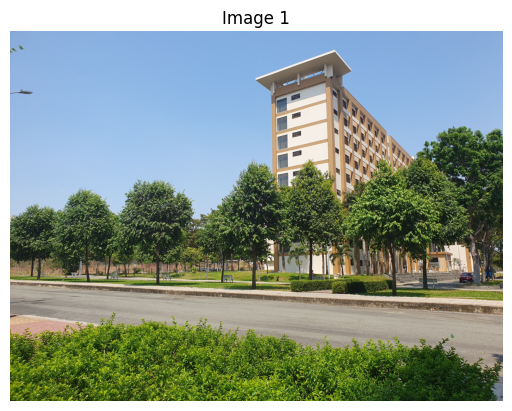

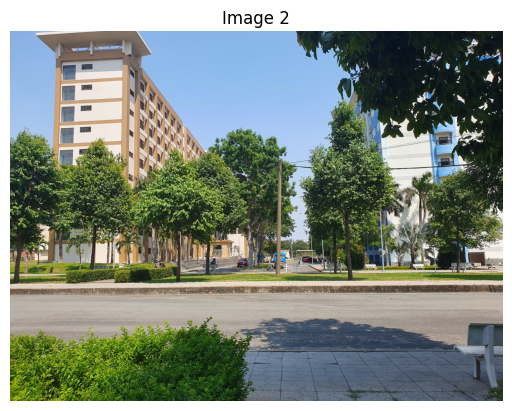

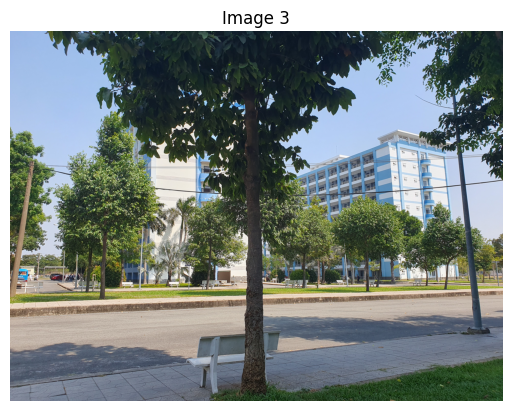

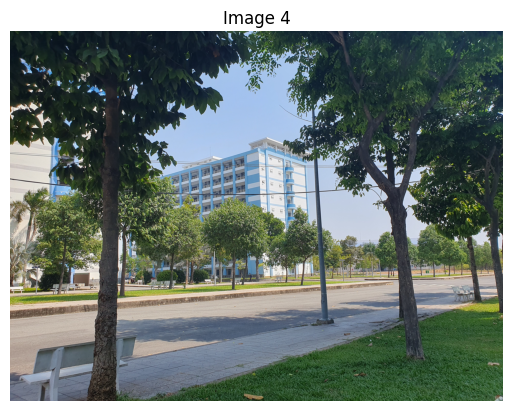

In [3]:
path1 = "../input/img1.jpg"
path2 = "../input/img2.jpg"
path3 = "../input/img3.jpg"
path4 = "../input/img4.jpg"

OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.exists(path1), f"Missing {path1}"
assert os.path.exists(path2), f"Missing {path2}"
assert os.path.exists(path3), f"Missing {path3}"
assert os.path.exists(path4), f"Missing {path4}"

img1 = cv2.imread(path1)
img2 = cv2.imread(path2)
img3 = cv2.imread(path3)
img4 = cv2.imread(path4)

# Convert sang RGB để hiển thị bằng matplotlib
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")
plt.show()

plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")
plt.show()

plt.imshow(img3)
plt.title("Image 3")
plt.axis("off")
plt.show()

plt.imshow(img4)
plt.title("Image 4")
plt.axis("off")
plt.show()

## 2. Chuyển ảnh sang grayscale

In [4]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
gray3 = cv2.cvtColor(img3, cv2.COLOR_RGB2GRAY)
gray4 = cv2.cvtColor(img4, cv2.COLOR_RGB2GRAY)

## 3. ORB Feature Detection

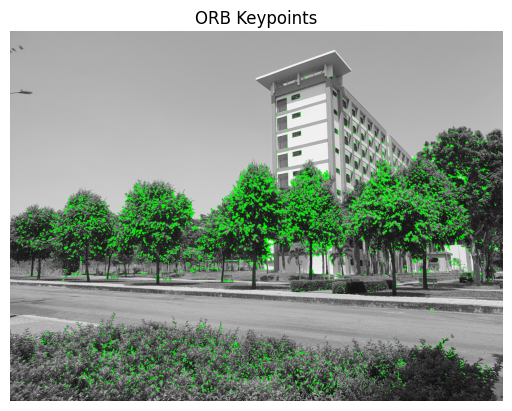

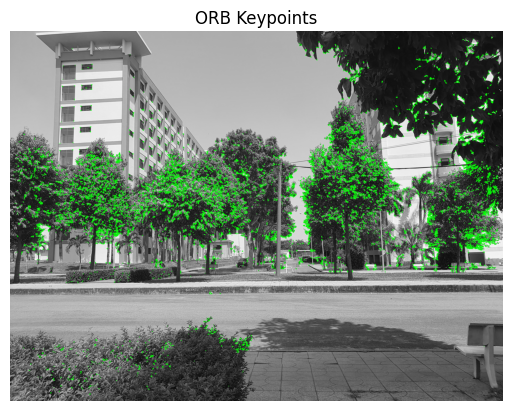

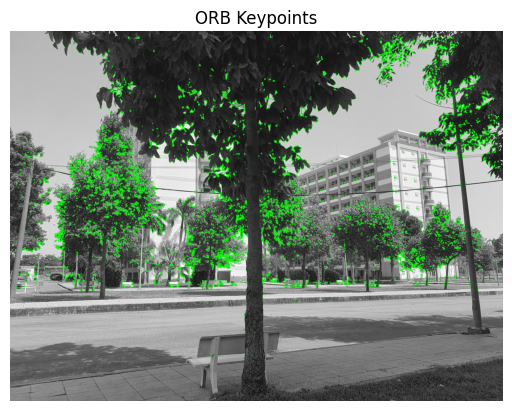

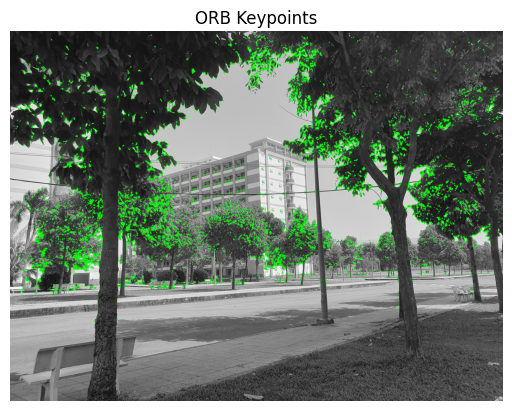

In [5]:
orb = cv2.ORB_create(nfeatures=50000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)
kp3, des3 = orb.detectAndCompute(gray3, None)
kp4, des4 = orb.detectAndCompute(gray4, None)

img_kp = cv2.drawKeypoints(gray1, kp1, None, color=(0,255,0))

plt.imshow(img_kp)
plt.title("ORB Keypoints")
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/ORB_img1.png", dpi=120, bbox_inches="tight")
plt.show()

img_kp = cv2.drawKeypoints(gray2, kp2, None, color=(0,255,0))

plt.imshow(img_kp)
plt.title("ORB Keypoints")
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/ORB_img2.png", dpi=120, bbox_inches="tight")
plt.show()

img_kp = cv2.drawKeypoints(gray3, kp3, None, color=(0,255,0))

plt.imshow(img_kp)
plt.title("ORB Keypoints")
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/ORB_img3.png", dpi=120, bbox_inches="tight")
plt.show()

img_kp = cv2.drawKeypoints(gray4, kp4, None, color=(0,255,0))

plt.imshow(img_kp)
plt.title("ORB Keypoints")
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/ORB_img4.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Feature Matching (KNN + Ratio Test)

In [6]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches1 = bf.knnMatch(des1, des2, k=2)
matches2 = bf.knnMatch(des2, des3, k=2)
matches3 = bf.knnMatch(des3, des4, k=2)

good1 = []
for m, n in matches1:
    if m.distance < 0.6 * n.distance:
        good1.append(m)

print("Số good matches img1:", len(good1))

good2 = []
for m, n in matches2:
    if m.distance < 0.6 * n.distance:
        good2.append(m)
        
print("Số good matches img2:", len(good2))

good3 = []
for m, n in matches3:
    if m.distance < 0.6 * n.distance:
        good3.append(m)     
        
print("Số good matches img3:", len(good3))

Số good matches img1: 651
Số good matches img2: 585
Số good matches img3: 864


## 5. Visualization Matches

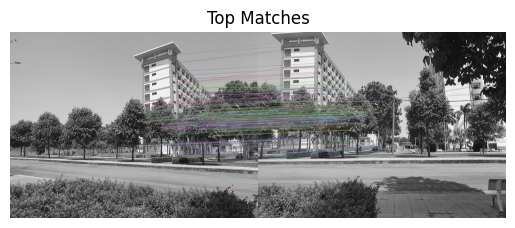

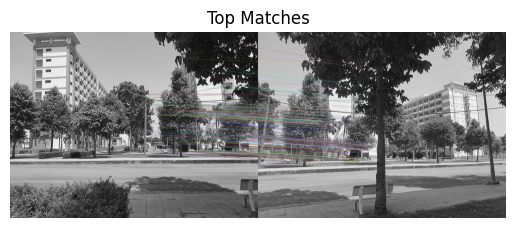

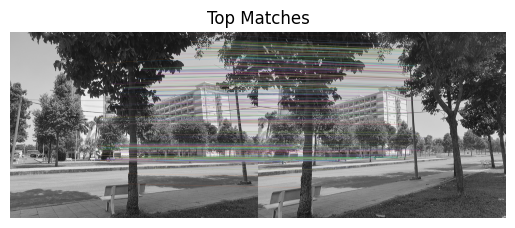

In [7]:
img_match_1 = cv2.drawMatches(gray1, kp1, gray2, kp2, good1, None, flags=2)

plt.imshow(img_match_1)
plt.title("Top Matches")
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/top_matches_img12.png", dpi=120, bbox_inches="tight")
plt.show()

img_match_2 = cv2.drawMatches(gray2, kp2, gray3, kp3, good2, None, flags=2)
plt.imshow(img_match_2)
plt.title("Top Matches")
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/top_matches_img23.png", dpi=120, bbox_inches="tight")
plt.show()

img_match_3 = cv2.drawMatches(gray3, kp3, gray4, kp4, good3, None, flags=2)
plt.imshow(img_match_3)
plt.title("Top Matches")
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/top_matches_img34.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Tính Homography (RANSAC)

In [8]:
pts1 = np.float32([kp1[m.queryIdx].pt for m in good1]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in good1]).reshape(-1,1,2)

H1, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)

num_inliers = np.sum(mask)  

print("Homography matrix img12:\n", H1)
print("Inliers img12:", num_inliers)

pts3 = np.float32([kp2[m.queryIdx].pt for m in good2]).reshape(-1,1,2)
pts4 = np.float32([kp3[m.trainIdx].pt for m in good2]).reshape(-1,1,2)

H2, mask = cv2.findHomography(pts4, pts3, cv2.RANSAC, 5.0)
num_inliers2 = np.sum(mask)

print("Homography matrix img23:\n", H2)
print("Inliers img23:", num_inliers2)

pts5 = np.float32([kp3[m.queryIdx].pt for m in good3]).reshape(-1,1,2)
pts6 = np.float32([kp4[m.trainIdx].pt for m in good3]).reshape(-1,1,2)

H3, mask = cv2.findHomography(pts6, pts5, cv2.RANSAC, 5.0)
num_inliers3 = np.sum(mask)

print("Homography matrix img34:\n", H3)
print("Inliers img34:", num_inliers3)

Homography matrix img12:
 [[ 4.01118382e-01 -1.66084526e-04  1.88505630e+03]
 [-2.55650694e-01  7.77540345e-01  4.38720244e+02]
 [-1.39875447e-04 -1.43729800e-05  1.00000000e+00]]
Inliers img12: 405
Homography matrix img23:
 [[ 4.36470821e-01  5.42966951e-02  2.01229081e+03]
 [-2.53315167e-01  8.38083348e-01  1.67483885e+02]
 [-1.34864389e-04 -4.01157607e-06  1.00000000e+00]]
Inliers img23: 368
Homography matrix img34:
 [[ 6.00605425e-01 -9.02389763e-03  1.29412518e+03]
 [-1.64245969e-01  8.33378833e-01  2.70192975e+02]
 [-9.32469594e-05 -7.77249894e-06  1.00000000e+00]]
Inliers img34: 484


## 7. Warp và Stitch ảnh

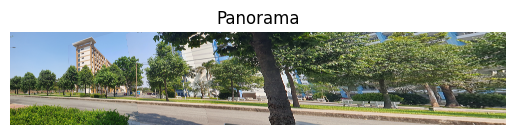

In [9]:

H21 = H1
H31 = H1 @ H2
H41 = H1 @ H2 @ H3   

h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
h3, w3 = img3.shape[:2]
h4, w4 = img4.shape[:2]

# canvas lớn hơn
canvas_w = w1 + w2 + w3 + w4
canvas_h = max(h1, h2, h3, h4)

result = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

# đặt img1 làm gốc
result[0:h1, 0:w1] = img1

# warp các ảnh còn lại
warp2 = cv2.warpPerspective(img2, H21, (canvas_w, canvas_h))
warp3 = cv2.warpPerspective(img3, H31, (canvas_w, canvas_h))
warp4 = cv2.warpPerspective(img4, H41, (canvas_w, canvas_h))

mask2 = (warp2 > 0)
result[mask2] = warp2[mask2]

mask3 = (warp3 > 0)
result[mask3] = warp3[mask3]

mask4 = (warp4 > 0)
result[mask4] = warp4[mask4]

plt.imshow(result) 
plt.title("Panorama") 
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/panorama_img1.png", dpi=120, bbox_inches="tight")
plt.show()

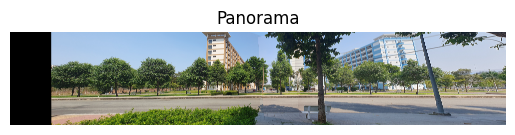

In [10]:
H12 = np.linalg.inv(H1)   # img1 → img2
H32 = H2                 # img3 → img2
H42 = H2 @ H3            # img4 → img2

result = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

# đặt img2 vào giữa
tx = canvas_w // 2 - w2 // 2
ty = canvas_h // 2 - h2 // 2

result[ty:ty+h2, tx:tx+w2] = img2

T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

warp1 = cv2.warpPerspective(img1, T @ H12, (canvas_w, canvas_h))
warp3 = cv2.warpPerspective(img3, T @ H32, (canvas_w, canvas_h))
warp4 = cv2.warpPerspective(img4, T @ H42, (canvas_w, canvas_h))

for warp in [warp1, warp3, warp4]:
    mask = np.any(warp > 0, axis=2)
    result[mask] = warp[mask]
    
plt.imshow(result) 
plt.title("Panorama") 
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/panorama_img2.png", dpi=120, bbox_inches="tight")
plt.show()

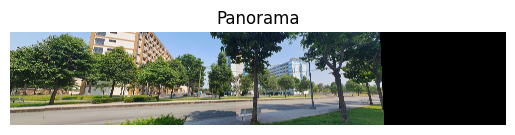

In [11]:
H13 = np.linalg.inv(H1 @ H2)   # img1 → img3
H23 = np.linalg.inv(H2)        # img2 → img3
H43 = H3                       # img4 → img3

result = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

# đặt img2 vào giữa
tx = canvas_w // 2 - w3 // 2
ty = canvas_h // 2 - h3 // 2

result[ty:ty+h3, tx:tx+w3] = img3

T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

warp1 = cv2.warpPerspective(img1, T @ H13, (canvas_w, canvas_h))
warp2 = cv2.warpPerspective(img2, T @ H23, (canvas_w, canvas_h))
warp4 = cv2.warpPerspective(img4, T @ H43, (canvas_w, canvas_h))

for warp in [warp1, warp2, warp4]:
    mask = np.any(warp > 0, axis=2)
    result[mask] = warp[mask]
    
plt.imshow(result) 
plt.title("Panorama") 
plt.axis("off")
plt.savefig(f"{OUTPUT_DIR}/panorama_img3.png", dpi=120, bbox_inches="tight")
plt.show()